# Delta 盈亏归因研究

这个 notebook 用来回答两个问题：

1. 模型和策略在哪些场景赚钱。
2. 模型和策略在哪些场景亏钱。

研究口径基于 `delta/demo.ipynb` 保存出来的模型，以及它对应的多日回测结果。

## 研究框架

- 先读已有多日结果，找到赚钱日和亏钱日。
- 再按 `StrategyDemo` 的真实逻辑逐秒重放单日信号，记录：`std_delta`、模型概率、波动率止损、开平仓动作。
- 最后把交易按 `entry_prob`、`entry_std_delta`、波动率、持仓时长、进场时段分桶，看利润集中在哪里。

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import sys
from collections import deque
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

for extra_path in [
    '/home/jovyan/work/tactics_demo',
    '/home/jovyan/work/tactics_demo/tools',
    '/home/jovyan/work/base_demo',
    '/home/jovyan/base_demo',
]:
    if extra_path not in sys.path:
        sys.path.append(extra_path)

import base_tool
from backtest_quick import backtest_quick, calculate_trade_stats
from delta.features import create_feature, latest_zscore

pd.set_option('display.max_rows', 40)
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)
plt.style.use('ggplot')

In [3]:
INSTRUMENT_ID = '511090'
TRAIN_PRESET = 'volatility_16d'
DEFAULT_RESULT_DIR = Path(
    '/home/jovyan/work/tactics_demo/backtest_result/511090_delta_v1_adaptive_volatility_16d_20260425_130210'
)
MODEL_PATH = Path(f'/home/jovyan/work/model/delta_{INSTRUMENT_ID}_{TRAIN_PRESET}.pkl')
MANUAL_FOCUS_DAY = None
PANEL_START_YMD = None
PANEL_END_YMD = None

assert MODEL_PATH.exists(), f'模型文件不存在: {MODEL_PATH}'
assert DEFAULT_RESULT_DIR.exists(), f'结果目录不存在: {DEFAULT_RESULT_DIR}'

print('model_path =', MODEL_PATH)
print('result_dir =', DEFAULT_RESULT_DIR)

model_path = /home/jovyan/work/model/delta_511090_volatility_16d.pkl
result_dir = /home/jovyan/work/tactics_demo/backtest_result/511090_delta_v1_adaptive_volatility_16d_20260425_130210


In [4]:
def load_param_dict(result_dir: Path) -> dict:
    with open(result_dir / 'parameters.json', 'r', encoding='utf-8') as f:
        param_dict = json.load(f)
    param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])
    return param_dict


def load_daily_summary(result_dir: Path) -> pd.DataFrame:
    daily_path = result_dir / 'daily_results.csv'
    daily_df = pd.read_csv(daily_path, dtype={'trade_ymd': str})
    daily_df['trade_date'] = pd.to_datetime(daily_df['trade_ymd'], format='%Y%m%d')
    daily_df['cum_profit'] = daily_df['profits'].cumsum()
    return daily_df.sort_values('trade_date').reset_index(drop=True)


def safe_qcut(series: pd.Series, q: int = 5) -> pd.Series:
    valid = series.dropna()
    if valid.empty or valid.nunique() < 2:
        return pd.Series(['all'] * len(series), index=series.index)
    bins = min(q, int(valid.nunique()))
    return pd.qcut(series, q=bins, duplicates='drop').astype(str)


def summarize_bucket(trades_df: pd.DataFrame, bucket_col: str) -> pd.DataFrame:
    if trades_df.empty:
        return pd.DataFrame()
    summary = (
        trades_df.groupby(bucket_col, dropna=False)
        .agg(
            trades=('pnl', 'size'),
            total_pnl=('pnl', 'sum'),
            avg_pnl=('pnl', 'mean'),
            median_pnl=('pnl', 'median'),
            win_rate=('win', 'mean'),
            avg_holding=('holding_ticks', 'mean'),
            avg_entry_prob=('entry_prob', 'mean'),
            avg_abs_std_delta=('abs_entry_std_delta', 'mean'),
        )
        .sort_values('total_pnl', ascending=False)
    )
    summary['win_rate'] = summary['win_rate'] * 100
    return summary.round(3)


def format_time_mark(value: int) -> str:
    return str(int(value)).zfill(6)


def add_time_features(df: pd.DataFrame, col: str) -> pd.DataFrame:
    out = df.copy()
    hhmmss = out[col].astype(int).map(format_time_mark)
    out[f'{col}_hh'] = hhmmss.str[:2].astype(int)
    out[f'{col}_hhmm'] = hhmmss.str[:4]
    out[f'{col}_minute_bucket'] = hhmmss.str[:4]
    return out


def replay_strategy_trace(model, param_dict: dict, snap_list: list[dict]) -> pd.DataFrame:
    feature_buffer = deque(maxlen=param_dict['x_window'])
    delta_buffer = deque(maxlen=param_dict['x_window'])
    price_buffer = deque(maxlen=param_dict['vol_window'])

    position_last = 0
    prev_signal = 0
    max_favorable_price = 0
    entry_price = 0
    holding_snap = 0

    rows = []
    threshold = float(model.best_threshold) + float(param_dict.get('open_confidence', 0))

    for snap in snap_list:
        price = snap.get('price_last')
        bid_book = snap.get('bid_book') or []
        ask_book = snap.get('ask_book') or []

        buy = bid_book[0][0] if bid_book else price
        sell = ask_book[0][0] if ask_book else price
        delta = sum(vol for _, vol in snap.get('buy_trade', [])[: param_dict['standard_num']]) - sum(
            vol for _, vol in snap.get('sell_trade', [])[: param_dict['standard_num']]
        )

        row = {
            'time_mark': int(snap['time_mark']),
            'time_hms': snap.get('time_hms'),
            'price_last': price,
            'bid_1': buy,
            'ask_1': sell,
            'delta': delta,
            'position_before': position_last,
            'prev_signal_before': prev_signal,
            'entry_price_before': entry_price,
            'holding_snap_before': holding_snap,
            'max_favorable_before': max_favorable_price,
            'std_delta': np.nan,
            'rolling_std': np.nan,
            'trailing_stop': np.nan,
            'dynamic_stop': np.nan,
            'pullback': np.nan,
            'prob': np.nan,
            'threshold': threshold,
            'open_candidate': 0,
            'entry_allowed': False,
            'stop_exit': False,
            'action': 'warmup',
            'position_after': position_last,
            'prev_signal_after': prev_signal,
            'entry_price_after': entry_price,
            'holding_snap_after': holding_snap,
            'max_favorable_after': max_favorable_price,
        }

        if not price:
            rows.append(row)
            continue

        price_buffer.append(price)
        if len(price_buffer) < param_dict['vol_window']:
            rows.append(row)
            continue

        delta_buffer.append(delta)
        if len(delta_buffer) < param_dict['x_window']:
            row['action'] = 'build_delta_window'
            rows.append(row)
            continue

        recent_delta = list(delta_buffer)[-param_dict['short_window'] :]
        std_delta = latest_zscore(recent_delta)
        row['std_delta'] = std_delta

        feature_buffer.append(snap)
        if len(feature_buffer) < param_dict['x_window']:
            row['action'] = 'build_feature_window'
            rows.append(row)
            continue

        feat_dict = create_feature(list(feature_buffer), param_dict['short_window'])
        for key, value in feat_dict.items():
            row[f'feat_{key}'] = value

        features = np.array([[feat_dict[key] for key in feat_dict.keys()]])
        proba = model.predict_proba(features)
        prob = float(proba.iloc[0, 1] if hasattr(proba, 'iloc') else proba[0, 1])
        row['prob'] = prob

        rolling_std = float(np.std(price_buffer))
        trailing_stop = rolling_std * param_dict['atr_multiplier']
        row['rolling_std'] = rolling_std
        row['trailing_stop'] = trailing_stop

        current_signal = prev_signal
        if position_last != 0:
            holding_snap += 1

        dynamic_stop = trailing_stop
        if position_last != 0 and holding_snap > param_dict.get('stop_tighten_start', 300):
            tighten_levels = (holding_snap - param_dict['stop_tighten_start']) // param_dict.get('stop_tighten_step', 150) + 1
            tighten_ratio = max(
                param_dict.get('stop_tighten_floor', 0.5),
                param_dict.get('stop_tighten_factor', 0.85) ** tighten_levels,
            )
            dynamic_stop *= tighten_ratio
        row['dynamic_stop'] = dynamic_stop

        pullback = np.nan
        stop_exit = False
        if position_last == 1:
            max_favorable_price = max(max_favorable_price, sell)
            pullback = max_favorable_price - sell
            if pullback >= dynamic_stop:
                current_signal = 0
                stop_exit = True
        elif position_last == -1:
            max_favorable_price = min(max_favorable_price, buy)
            pullback = buy - max_favorable_price
            if pullback >= dynamic_stop:
                current_signal = 0
                stop_exit = True
        row['pullback'] = pullback
        row['stop_exit'] = stop_exit

        open_candidate = 0
        if position_last == 0:
            if std_delta > param_dict['open_threshold']:
                current_signal = 1
                open_candidate = 1
            elif std_delta < -param_dict['open_threshold']:
                current_signal = -1
                open_candidate = -1
        row['open_candidate'] = open_candidate

        entry_allowed = bool(prob > threshold)
        row['entry_allowed'] = entry_allowed

        if current_signal != prev_signal:
            if position_last != 0:
                position_last = 0
                prev_signal = 0
                max_favorable_price = 0
                entry_price = 0
                holding_snap = 0
                row['action'] = 'close_stop' if stop_exit else 'close_signal'
            else:
                if entry_allowed:
                    position_last = current_signal
                    prev_signal = current_signal
                    entry_price = price
                    holding_snap = 0
                    if current_signal == 1:
                        max_favorable_price = sell
                        row['action'] = 'open_long'
                    else:
                        max_favorable_price = buy
                        row['action'] = 'open_short'
                else:
                    row['action'] = 'blocked_open'
        else:
            row['action'] = 'hold' if position_last != 0 else 'flat'

        row['position_after'] = position_last
        row['prev_signal_after'] = prev_signal
        row['entry_price_after'] = entry_price
        row['holding_snap_after'] = holding_snap
        row['max_favorable_after'] = max_favorable_price
        rows.append(row)

    trace_df = pd.DataFrame(rows)
    trace_df['position_change'] = trace_df['position_after'].diff().fillna(trace_df['position_after'])
    return trace_df


def build_trade_frame(trace_df: pd.DataFrame, profit_df: pd.DataFrame) -> pd.DataFrame:
    trades = pd.DataFrame(profit_df.attrs.get('trades', [])).copy()
    if trades.empty:
        return trades

    entry_cols = [
        'time_mark', 'prob', 'std_delta', 'rolling_std', 'trailing_stop', 'dynamic_stop', 'delta',
        'feat_num_trades', 'feat_volatility', 'feat_spread', 'feat_WAMP', 'feat_volume',
        'feat_alpha_01', 'feat_alpha_02', 'feat_alpha_03', 'feat_alpha_04', 'feat_alpha_05',
        'feat_alpha_06', 'feat_alpha_07'
    ]
    exit_cols = ['time_mark', 'pullback', 'dynamic_stop', 'rolling_std', 'trailing_stop', 'price_last']

    entry_trace = trace_df[entry_cols].rename(columns={c: f'entry_{c}' for c in entry_cols if c != 'time_mark'})
    exit_trace = trace_df[exit_cols].rename(columns={c: f'exit_{c}' for c in exit_cols if c != 'time_mark'})

    trades = trades.merge(entry_trace, left_on='entry_time', right_on='time_mark', how='left').drop(columns=['time_mark'])
    trades = trades.merge(exit_trace, left_on='exit_time', right_on='time_mark', how='left').drop(columns=['time_mark'])

    trades['holding_ticks'] = trades['exit_time'] - trades['entry_time']
    trades['abs_entry_std_delta'] = trades['entry_std_delta'].abs()
    trades['entry_prob_rank'] = trades['entry_prob'].rank(pct=True)
    trades['entry_vol_rank'] = trades['entry_feat_volatility'].rank(pct=True)
    trades = add_time_features(trades, 'entry_time')
    trades = add_time_features(trades, 'exit_time')
    trades['pnl_bp_on_entry'] = np.where(
        trades['entry_price'] != 0,
        trades['pnl'] / (trades['entry_price'] * 100) * 10000,
        np.nan,
    )
    trades['reason_guess'] = np.where(
        trades['exit_pullback'] >= trades['exit_dynamic_stop'],
        'trailing_stop',
        'other',
    )
    trades['entry_prob_bucket'] = safe_qcut(trades['entry_prob'], q=5)
    trades['entry_std_bucket'] = safe_qcut(trades['abs_entry_std_delta'], q=5)
    trades['entry_vol_bucket'] = safe_qcut(trades['entry_feat_volatility'], q=5)
    trades['holding_bucket'] = safe_qcut(trades['holding_ticks'], q=5)
    return trades.sort_values('entry_time').reset_index(drop=True)


def analyze_one_day(instrument_id: str, trade_ymd: str, model_path: Path, param_dict: dict):
    model = joblib.load(model_path)
    snap_list = base_tool.snap_list_load(instrument_id, trade_ymd)
    assert snap_list, f'无 snapshot 数据: {instrument_id} {trade_ymd}'

    trace_df = replay_strategy_trace(model, param_dict, snap_list)
    position_dict = dict(zip(trace_df['time_mark'], trace_df['position_after']))
    profit_df = backtest_quick(instrument_id, trade_ymd, param_dict['name'], position_dict, remake=True)
    trades_df = build_trade_frame(trace_df, profit_df)
    return trace_df, profit_df, trades_df


def collect_trade_panel(
    daily_df: pd.DataFrame,
    instrument_id: str,
    model_path: Path,
    param_dict: dict,
    start_ymd: str | None = None,
    end_ymd: str | None = None,
) -> pd.DataFrame:
    if daily_df.empty:
        return pd.DataFrame()

    selected_daily_df = daily_df.copy()
    if start_ymd is not None:
        selected_daily_df = selected_daily_df[selected_daily_df['trade_ymd'] >= start_ymd]
    if end_ymd is not None:
        selected_daily_df = selected_daily_df[selected_daily_df['trade_ymd'] <= end_ymd]

    chosen_days = selected_daily_df['trade_ymd'].drop_duplicates().tolist()
    print(f'collect_trade_panel: {len(chosen_days)} days selected')

    frames = []
    for trade_ymd in chosen_days:
        trace_df, profit_df, trades_df = analyze_one_day(instrument_id, trade_ymd, model_path, param_dict)
        if trades_df.empty:
            continue
        trades_df = trades_df.copy()
        trades_df['trade_ymd'] = trade_ymd
        trades_df['day_profit'] = float(profit_df['profits'].iloc[-1])
        frames.append(trades_df)

    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


def plot_intraday_research(trace_df: pd.DataFrame, profit_df: pd.DataFrame, trades_df: pd.DataFrame, title: str):
    fig, axes = plt.subplots(4, 1, figsize=(18, 16), sharex=True)
    x = np.arange(len(trace_df))

    axes[0].plot(x, trace_df['price_last'], color='black', linewidth=1.0, label='price_last')
    open_long = trace_df[trace_df['action'] == 'open_long']
    open_short = trace_df[trace_df['action'] == 'open_short']
    close_sig = trace_df[trace_df['action'].isin(['close_stop', 'close_signal'])]
    axes[0].scatter(open_long.index, open_long['price_last'], marker='^', color='red', s=35, label='open_long')
    axes[0].scatter(open_short.index, open_short['price_last'], marker='v', color='green', s=35, label='open_short')
    axes[0].scatter(close_sig.index, close_sig['price_last'], marker='o', color='blue', s=20, label='close')
    axes[0].set_ylabel('price')
    axes[0].legend(loc='upper left')
    axes[0].set_title(title)

    profit_curve = profit_df['profits'].values if profit_df is not None else np.zeros(len(trace_df))
    axes[1].plot(np.arange(len(profit_curve)), profit_curve, color='#1f77b4', linewidth=1.2)
    axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
    axes[1].set_ylabel('cum pnl')

    axes[2].plot(x, trace_df['prob'], color='#ff7f0e', linewidth=1.0, label='model prob')
    axes[2].axhline(trace_df['threshold'].dropna().iloc[0], color='black', linestyle='--', linewidth=0.8, label='entry threshold')
    axes[2].set_ylabel('prob')
    axes[2].legend(loc='upper left')

    axes[3].plot(x, trace_df['std_delta'], color='#2ca02c', linewidth=1.0, label='std_delta')
    axes[3].axhline(param_dict['open_threshold'], color='red', linestyle='--', linewidth=0.8)
    axes[3].axhline(-param_dict['open_threshold'], color='red', linestyle='--', linewidth=0.8)
    axes[3].set_ylabel('std_delta')
    axes[3].legend(loc='upper left')
    axes[3].set_xlabel('snapshot index')
    plt.tight_layout()

    if not trades_df.empty:
        fig, ax = plt.subplots(figsize=(8, 6))
        colors = np.where(trades_df['pnl'] > 0, 'red', 'green')
        ax.scatter(trades_df['entry_prob'], trades_df['pnl'], c=colors, alpha=0.75)
        ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
        ax.set_xlabel('entry_prob')
        ax.set_ylabel('trade pnl')
        ax.set_title('Entry Probability vs Trade PnL')
        plt.tight_layout()


param_dict = load_param_dict(DEFAULT_RESULT_DIR)
daily_df = load_daily_summary(DEFAULT_RESULT_DIR)

In [5]:
summary_path = DEFAULT_RESULT_DIR / 'summary.json'
summary_dict = json.loads(summary_path.read_text())
pd.Series(summary_dict, name='value')

测试天数             79.00
累计总盈亏           811.90
总成交次数           791.00
盈利交易次数          323.00
亏损交易次数          468.00
加权每手胜率%          40.83
日均盈亏             10.28
胜率(天)%           64.56
盈亏比(日均)           1.93
最大单日盈利           58.40
最大单日亏损          -40.10
每笔交易平均盈利          1.03
加权平均持仓时间(快照)    813.88
Name: value, dtype: float64

,trade_ymd,profits,trades,win_rate,avg_holding_ticks
4,20250911,58.4,3,100.00,1512.67
56,20260213,54.4,8,75.00,1362.00
32,20251205,48.2,3,66.67,1475.00
44,20260109,46.6,7,85.71,1381.14
2,20250905,46.4,1,100.00,2785.00
1,20250903,45.5,5,100.00,1287.40
53,20260205,44.3,10,60.00,950.30
7,20250919,43.5,5,60.00,864.60


,trade_ymd,profits,trades,win_rate,avg_holding_ticks
12,20251013,-40.1,10,20.00,507.50
39,20251225,-28.6,16,25.00,519.31
18,20251029,-24.3,10,20.00,594.80
78,20260423,-21.4,12,33.33,578.50
5,20250915,-18.5,10,20.00,574.60
30,20251201,-17.8,16,31.25,630.94
70,20260401,-17.3,14,7.14,697.14
10,20250929,-14.6,5,20.00,324.80


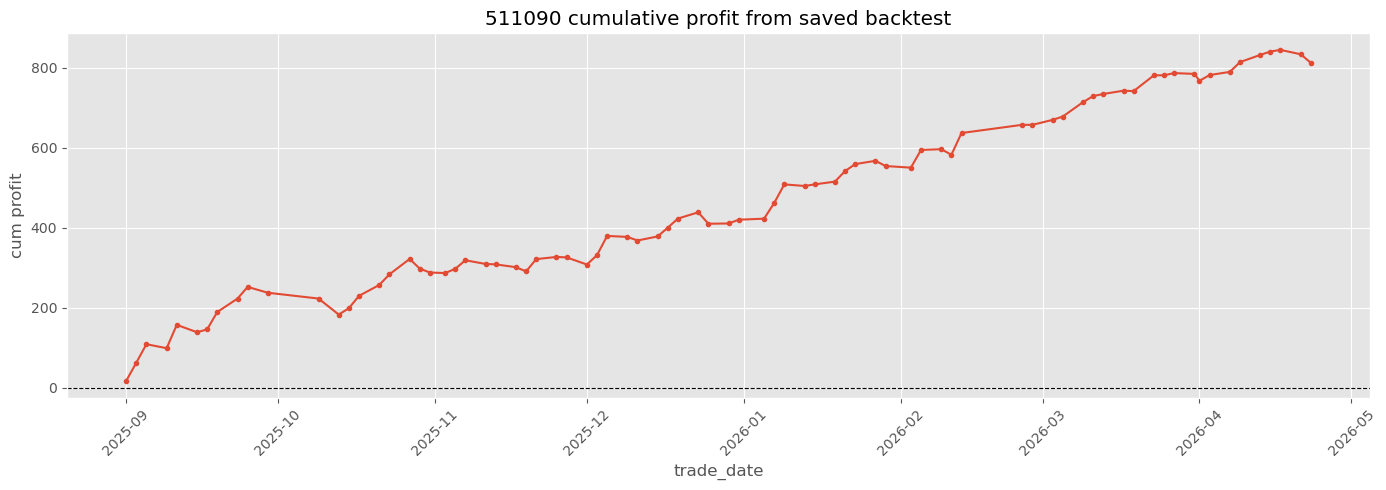

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_df['trade_date'], daily_df['cum_profit'], marker='o', markersize=3)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title(f'{INSTRUMENT_ID} cumulative profit from saved backtest')
ax.set_xlabel('trade_date')
ax.set_ylabel('cum profit')
plt.xticks(rotation=45)
plt.tight_layout()

display(daily_df.nlargest(8, 'profits')[['trade_ymd', 'profits', 'trades', 'win_rate', 'avg_holding_ticks']])
display(daily_df.nsmallest(8, 'profits')[['trade_ymd', 'profits', 'trades', 'win_rate', 'avg_holding_ticks']])

In [7]:
focus_trade_ymd = MANUAL_FOCUS_DAY or daily_df.sort_values('profits').iloc[0]['trade_ymd']
focus_trade_ymd

'20251013'

In [8]:
trace_df, profit_df, trades_df = analyze_one_day(INSTRUMENT_ID, focus_trade_ymd, MODEL_PATH, param_dict)

print('focus day:', focus_trade_ymd)
print('day pnl:', float(profit_df['profits'].iloc[-1]))
print('trade stats:', calculate_trade_stats(profit_df.attrs.get('trades', [])))
print('actions:')
display(trace_df['action'].value_counts())
display(trades_df[['entry_time', 'exit_time', 'position', 'entry_prob', 'entry_std_delta', 'holding_ticks', 'pnl', 'reason_guess']].sort_values('pnl'))

focus day: 20251013
day pnl: -35.59999999999491
trade stats: {'total_trades': 9, 'win_trades': 2, 'loss_trades': 7, 'win_rate': 0.2222222222222222, 'total_pnl': np.float64(-35.599999999999454), 'avg_pnl_per_trade': np.float64(-3.955555555555495), 'avg_win': np.float64(2.850000000000108), 'avg_loss': np.float64(5.899999999999953), 'profit_factor': np.float64(0.48305084745764926)}
actions:


action
flat                    7618
hold                    4843
warmup                   599
build_delta_window       599
build_feature_window     599
blocked_open             127
open_long                  8
close_stop                 8
open_short                 1
Name: count, dtype: int64

,entry_time,exit_time,position,entry_prob,entry_std_delta,holding_ticks,pnl,reason_guess
3,1760333488000,1760334099000,1.0,0.644501,-0.076258,611000,-13.0,other
6,1760336329000,1760336809000,1.0,0.514435,-0.372163,480000,-7.4,other
7,1760336933000,1760337758000,1.0,0.505940,1.330569,825000,-5.5,other
1,1760332302000,1760332496000,1.0,0.693411,12.503712,194000,-4.6,other
4,1760334514000,1760334704000,1.0,0.634629,-0.521426,190000,-3.9,other
0,1760324974000,1760325270000,1.0,0.552505,0.217440,296000,-3.7,other
2,1760332619000,1760332980000,1.0,0.595049,-0.290322,361000,-3.2,other
8,1760337909000,1760338201000,1.0,0.616613,0.088333,292000,1.6,other
5,1760334714000,1760335716000,-1.0,0.648752,-0.130754,1002000,4.1,other


In [9]:
display(summarize_bucket(trades_df, 'entry_prob_bucket'))
display(summarize_bucket(trades_df, 'entry_std_bucket'))
display(summarize_bucket(trades_df, 'entry_vol_bucket'))
display(summarize_bucket(trades_df, 'holding_bucket'))

time_bucket_summary = (
    trades_df.groupby('entry_time_minute_bucket')
    .agg(trades=('pnl', 'size'), total_pnl=('pnl', 'sum'), avg_pnl=('pnl', 'mean'), win_rate=('win', 'mean'))
    .sort_values('total_pnl', ascending=False)
)
time_bucket_summary['win_rate'] = time_bucket_summary['win_rate'] * 100
display(time_bucket_summary.head(15))
display(time_bucket_summary.tail(15))

,trades,total_pnl,avg_pnl,median_pnl,win_rate,avg_holding,avg_entry_prob,avg_abs_std_delta
entry_prob_bucket,,,,,,,,
"(0.599, 0.631]",1,1.6,1.60,1.60,100.0,292000.0,0.617,0.088
"(0.646, 0.693]",2,-0.5,-0.25,-0.25,50.0,598000.0,0.671,6.317
"(0.537, 0.599]",2,-6.9,-3.45,-3.45,0.0,328500.0,0.574,0.254
"(0.505, 0.537]",2,-12.9,-6.45,-6.45,0.0,652500.0,0.510,0.851
"(0.631, 0.646]",2,-16.9,-8.45,-8.45,0.0,400500.0,0.640,0.299


,trades,total_pnl,avg_pnl,median_pnl,win_rate,avg_holding,avg_entry_prob,avg_abs_std_delta
entry_std_bucket,,,,,,,,
"(0.114, 0.232]",2,0.4,0.20,0.20,50.0,649000.0,0.601,0.174
"(0.232, 0.356]",1,-3.2,-3.20,-3.20,0.0,361000.0,0.595,0.290
"(0.845, 12.504]",2,-10.1,-5.05,-5.05,0.0,509500.0,0.600,6.917
"(0.356, 0.845]",2,-11.3,-5.65,-5.65,0.0,335000.0,0.575,0.447
"(0.0753, 0.114]",2,-11.4,-5.70,-5.70,50.0,451500.0,0.631,0.082


,trades,total_pnl,avg_pnl,median_pnl,win_rate,avg_holding,avg_entry_prob,avg_abs_std_delta
entry_vol_bucket,,,,,,,,
"(0.000104, 0.000112]",1,1.6,1.60,1.60,100.0,292000.0,0.617,0.088
"(-0.0009148, 9.36e-05]",2,-0.5,-0.25,-0.25,50.0,598000.0,0.671,6.317
"(0.000112, 0.000126]",2,-6.9,-3.45,-3.45,0.0,328500.0,0.574,0.254
"(0.000126, 0.000151]",2,-12.9,-6.45,-6.45,0.0,652500.0,0.510,0.851
"(9.36e-05, 0.000104]",2,-16.9,-8.45,-8.45,0.0,400500.0,0.640,0.299


,trades,total_pnl,avg_pnl,median_pnl,win_rate,avg_holding,avg_entry_prob,avg_abs_std_delta
holding_bucket,,,,,,,,
"(696600.0, 1002000.0]",2,-1.4,-0.70,-0.70,50.0,913500.0,0.577,0.731
"(252800.0, 309000.0]",2,-2.1,-1.05,-1.05,50.0,294000.0,0.585,0.153
"(309000.0, 456200.0]",1,-3.2,-3.20,-3.20,0.0,361000.0,0.595,0.290
"(189999.999, 252800.0]",2,-8.5,-4.25,-4.25,0.0,192000.0,0.664,6.513
"(456200.0, 696600.0]",2,-20.4,-10.20,-10.20,0.0,545500.0,0.579,0.224


,trades,total_pnl,avg_pnl,win_rate
entry_time_minute_bucket,,,,
1760,9,-35.6,-3.955556,22.222222


,trades,total_pnl,avg_pnl,win_rate
entry_time_minute_bucket,,,,
1760,9,-35.6,-3.955556,22.222222


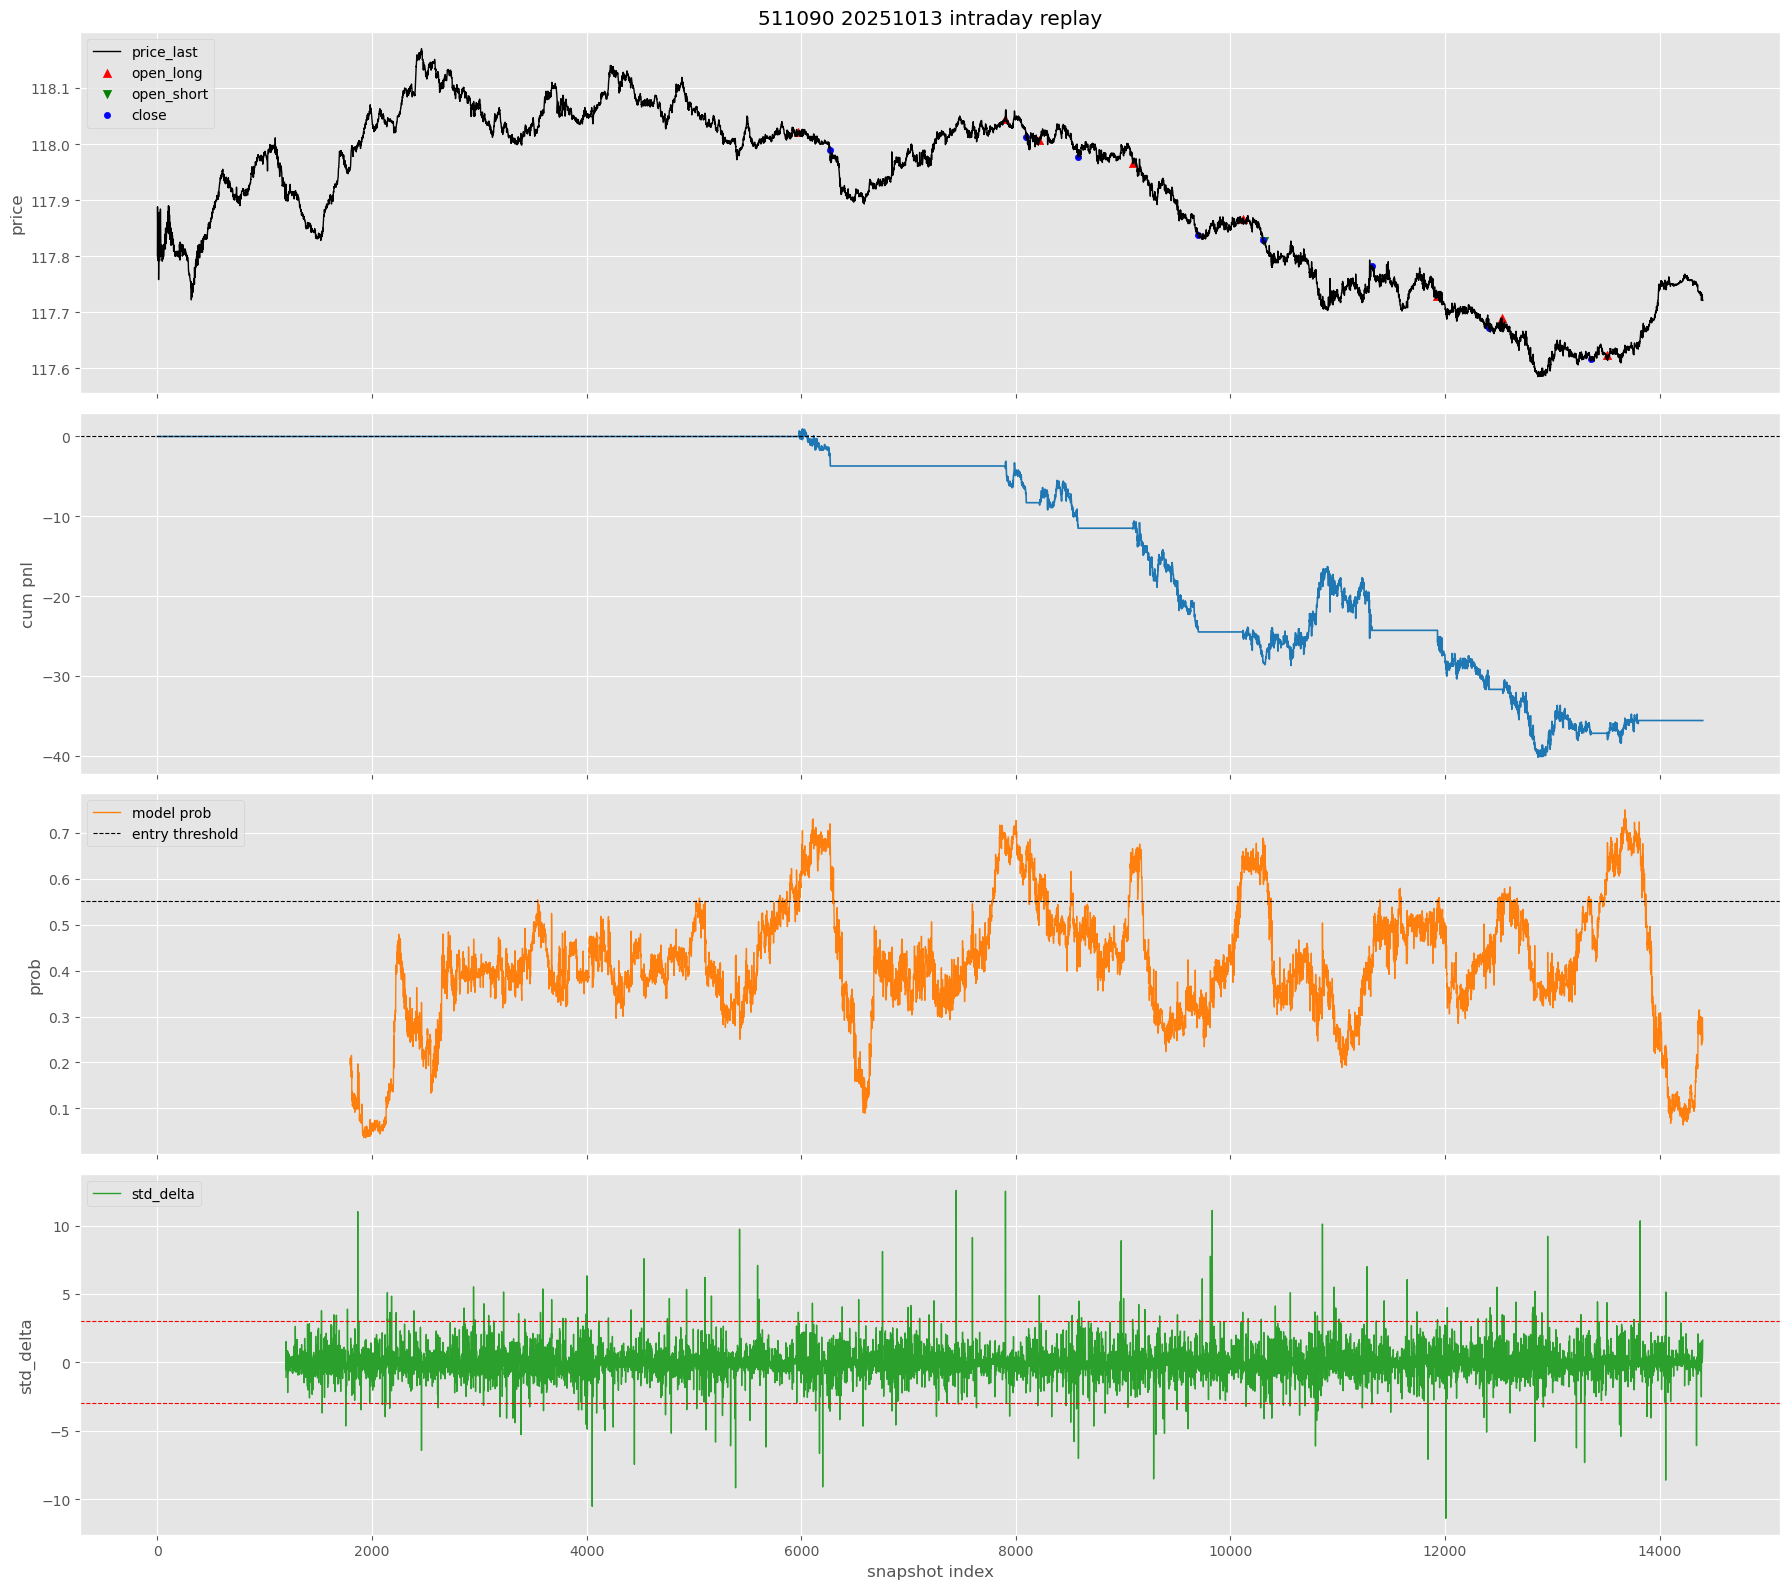

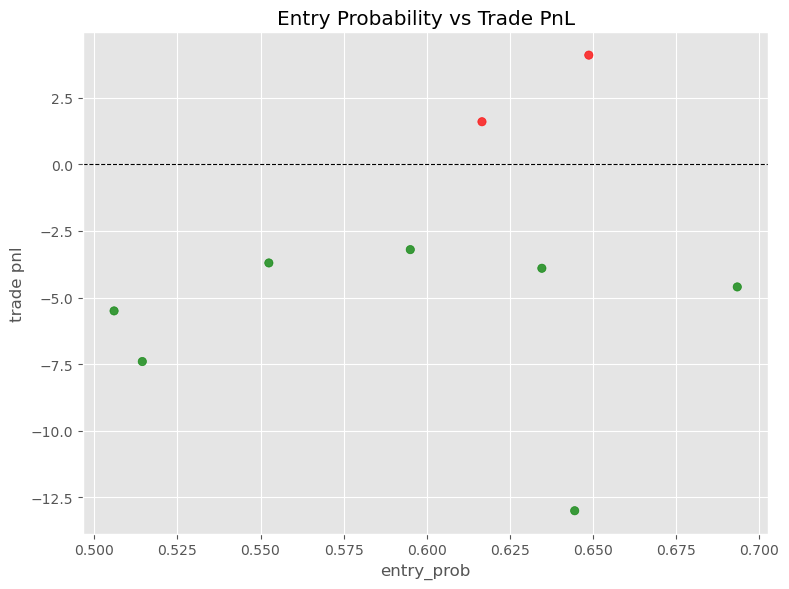

In [10]:
plot_intraday_research(trace_df, profit_df, trades_df, title=f'{INSTRUMENT_ID} {focus_trade_ymd} intraday replay')

## 多日交易面板

下面默认把保存结果里的全样本交易都拼成一个交易面板，用来观察：

- 高概率入场是否真的更赚钱。
- 强 `std_delta` 入场是贡献利润还是制造回撤。
- 长持仓是否在放大利润，还是在拖累止损。

如果只想看某个时间段，可以在配置区设置 `PANEL_START_YMD` 和 `PANEL_END_YMD`。

In [11]:
panel_trades_df = collect_trade_panel(
    daily_df,
    INSTRUMENT_ID,
    MODEL_PATH,
    param_dict,
    start_ymd=PANEL_START_YMD,
    end_ymd=PANEL_END_YMD,
)
panel_trades_df[['trade_ymd', 'entry_time', 'position', 'entry_prob', 'entry_std_delta', 'holding_ticks', 'pnl']].head()

collect_trade_panel: 79 days selected


,trade_ymd,entry_time,position,entry_prob,entry_std_delta,holding_ticks,pnl
0,20250901,1756693873000,-1.0,0.589368,-0.121484,2092000,8.9
1,20250901,1756703188000,-1.0,0.599321,0.558539,934000,-2.8
2,20250901,1756705017000,1.0,0.563352,-0.080029,1133000,7.6
3,20250901,1756706306000,-1.0,0.580424,1.655106,1184000,-2.1
4,20250901,1756707775000,1.0,0.549815,-0.481079,1626000,5.3


In [12]:
print('panel trade count =', len(panel_trades_df))
print('panel day count =', panel_trades_df['trade_ymd'].nunique())
print('panel total pnl =', round(panel_trades_df['pnl'].sum(), 3))
print('panel date range =', panel_trades_df['trade_ymd'].min(), '~', panel_trades_df['trade_ymd'].max())

display(summarize_bucket(panel_trades_df, 'entry_prob_bucket'))
display(summarize_bucket(panel_trades_df, 'entry_std_bucket'))
display(summarize_bucket(panel_trades_df, 'entry_vol_bucket'))
display(summarize_bucket(panel_trades_df, 'holding_bucket'))

side_summary = (
    panel_trades_df.groupby('position')
    .agg(trades=('pnl', 'size'), total_pnl=('pnl', 'sum'), avg_pnl=('pnl', 'mean'), win_rate=('win', 'mean'))
)
side_summary['win_rate'] = side_summary['win_rate'] * 100
display(side_summary.round(3))

reason_summary = (
    panel_trades_df.groupby('reason_guess')
    .agg(trades=('pnl', 'size'), total_pnl=('pnl', 'sum'), avg_pnl=('pnl', 'mean'), win_rate=('win', 'mean'))
)
reason_summary['win_rate'] = reason_summary['win_rate'] * 100
display(reason_summary.round(3))

panel trade count = 786
panel day count = 79
panel total pnl = 833.9
panel date range = 20250901 ~ 20260423


,trades,total_pnl,avg_pnl,median_pnl,win_rate,avg_holding,avg_entry_prob,avg_abs_std_delta
entry_prob_bucket,,,,,,,,
all,1,46.4,46.40,46.40,100.0,2785000.000,0.646,0.739
"(0.522, 0.551]",1,46.3,46.30,46.30,100.0,8500000.000,0.551,0.075
"(0.589, 0.608]",1,41.0,41.00,41.00,100.0,2066000.000,0.603,2.410
"(0.598, 0.63]",1,38.0,38.00,38.00,100.0,7979000.000,0.598,0.058
"(0.677, 0.749]",2,37.1,18.55,18.55,50.0,5116000.000,0.730,0.321
...,...,...,...,...,...,...,...,...
"(0.526, 0.543]",3,-14.4,-4.80,-5.00,0.0,256333.333,0.532,0.383
"(0.374, 0.534]",2,-15.1,-7.55,-7.55,0.0,659000.000,0.430,1.505
"(0.53, 0.566]",4,-15.6,-3.90,-3.70,0.0,311250.000,0.545,0.700


,trades,total_pnl,avg_pnl,median_pnl,win_rate,avg_holding,avg_entry_prob,avg_abs_std_delta
entry_std_bucket,,,,,,,,
all,1,46.4,46.400,46.40,100.0,2785000.000,0.646,0.739
"(0.0741, 0.57]",1,46.3,46.300,46.30,100.0,8500000.000,0.551,0.075
"(2.299, 2.41]",1,41.0,41.000,41.00,100.0,2066000.000,0.603,2.410
"(0.0386, 0.0598]",2,38.5,19.250,19.25,100.0,4374000.000,0.625,0.049
"(0.342, 0.425]",2,35.1,17.550,17.55,50.0,5196500.000,0.663,0.361
...,...,...,...,...,...,...,...,...
"(0.0422, 0.251]",4,-12.2,-3.050,-3.00,0.0,289000.000,0.575,0.145
"(0.0544, 0.0977]",3,-12.7,-4.233,-3.90,0.0,432666.667,0.630,0.067
"(0.318, 1.083]",3,-12.8,-4.267,-1.20,0.0,667333.333,0.620,0.723


,trades,total_pnl,avg_pnl,median_pnl,win_rate,avg_holding,avg_entry_prob,avg_abs_std_delta
entry_vol_bucket,,,,,,,,
all,1,46.4,46.400,46.40,100.0,2785000.0,0.646,0.739
"(-0.000846, 0.00017]",1,46.3,46.300,46.30,100.0,8500000.0,0.551,0.075
"(9.031e-05, 0.0001115]",1,41.0,41.000,41.00,100.0,2066000.0,0.603,2.410
"(-0.0009615, 6.14e-05]",2,38.5,19.250,19.25,100.0,4374000.0,0.625,0.049
"(-0.0009501000000000001, 6.3e-05]",2,36.4,18.200,18.20,50.0,5021000.0,0.702,0.497
...,...,...,...,...,...,...,...,...
"(9.89e-05, 0.000115]",3,-12.7,-4.233,-1.10,0.0,633000.0,0.589,0.607
"(0.000126, 0.000151]",2,-12.9,-6.450,-6.45,0.0,652500.0,0.510,0.851
"(0.000118, 0.000127]",2,-14.3,-7.150,-7.15,0.0,184500.0,0.552,0.628


,trades,total_pnl,avg_pnl,median_pnl,win_rate,avg_holding,avg_entry_prob,avg_abs_std_delta
holding_bucket,,,,,,,,
all,1,46.4,46.400,46.40,100.0,2785000.000,0.646,0.739
"(3371333.333, 8500000.0]",1,46.3,46.300,46.30,100.0,8500000.000,0.551,0.075
"(970200.0, 2811000.0]",2,45.5,22.750,22.75,100.0,2381000.000,0.567,0.646
"(1935200.0, 7979000.0]",2,42.7,21.350,21.35,100.0,5006500.000,0.590,0.060
"(1314200.0, 2829800.0]",1,41.0,41.000,41.00,100.0,2066000.000,0.603,2.410
...,...,...,...,...,...,...,...,...
"(221999.999, 399600.0]",3,-12.5,-4.167,-4.30,0.0,278666.667,0.604,0.486
"(249000.0, 367000.0]",3,-12.5,-4.167,-4.30,0.0,332000.000,0.538,0.893
"(433600.0, 637400.0]",3,-14.6,-4.867,-2.90,0.0,568000.000,0.626,0.801


,trades,total_pnl,avg_pnl,win_rate
position,,,,
-1.0,383,485.2,1.267,42.559
1.0,403,348.7,0.865,39.454


,trades,total_pnl,avg_pnl,win_rate
reason_guess,,,,
other,786,833.9,1.061,40.967


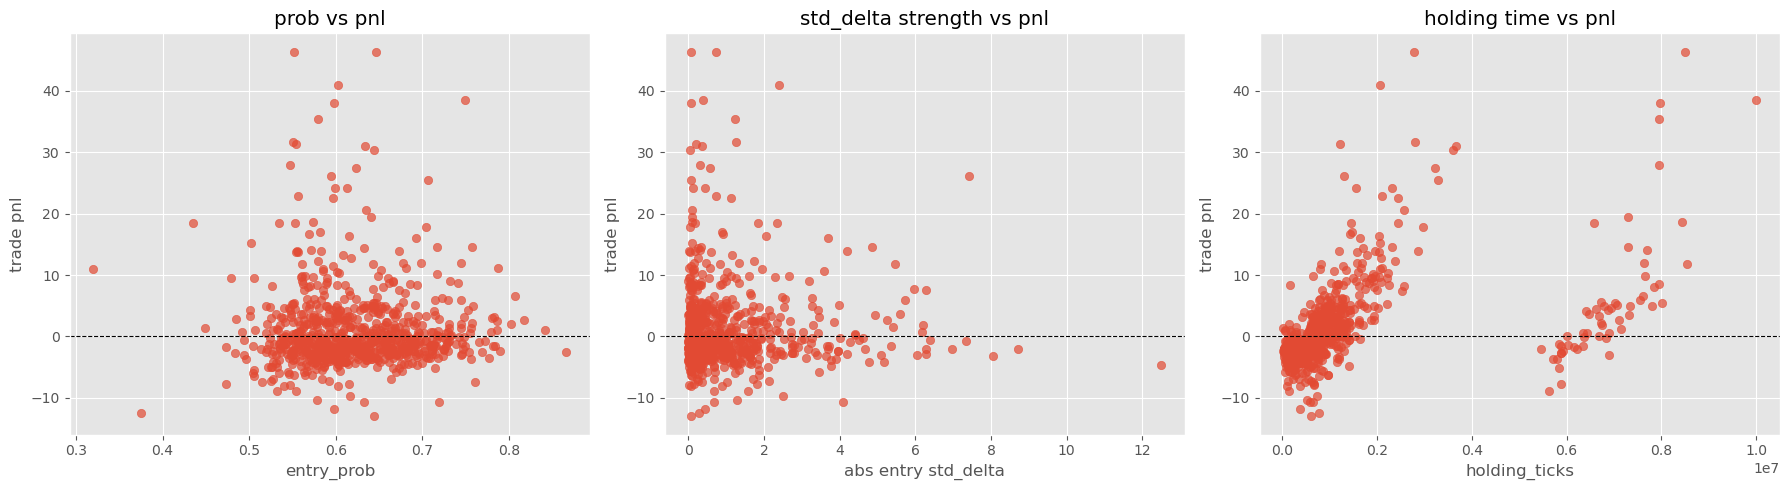

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(panel_trades_df['entry_prob'], panel_trades_df['pnl'], alpha=0.7)
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('entry_prob')
axes[0].set_ylabel('trade pnl')
axes[0].set_title('prob vs pnl')

axes[1].scatter(panel_trades_df['abs_entry_std_delta'], panel_trades_df['pnl'], alpha=0.7)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('abs entry std_delta')
axes[1].set_ylabel('trade pnl')
axes[1].set_title('std_delta strength vs pnl')

axes[2].scatter(panel_trades_df['holding_ticks'], panel_trades_df['pnl'], alpha=0.7)
axes[2].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[2].set_xlabel('holding_ticks')
axes[2].set_ylabel('trade pnl')
axes[2].set_title('holding time vs pnl')

plt.tight_layout()

## 下一步建议

如果你要继续往前推，可以直接在这个 notebook 里做三种扩展：

- 把 `panel_trades_df` 扩成全样本，而不是只看最赚钱和最亏钱的几天。
- 增加“按止损退出 / 按尾盘平仓 / 按反向信号退出”的更精确标签。
- 针对亏损桶反推参数，例如提高 `open_confidence`，或者限制某些低波动、低概率时段不开仓。